# Confidence Thresholds

In [382]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/processed/')
KEYPOINT_DIR = DATA_DIR / 'keypoints'

MOVENET_DIR = KEYPOINT_DIR / 'movenet'
MEDIAPIPE_DIR = KEYPOINT_DIR / 'mediapipe_norm'
OUT_DIR = DATA_DIR / 'confidence_stats'

JOINTS = [
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle',
]

In [383]:
def load_files(path):
    files = []
    for file in path.rglob('*.csv'):
        files.append(pd.read_csv(file))
    return files


movenet_files = load_files(MOVENET_DIR)
mediapipe_files = load_files(MEDIAPIPE_DIR)

print(f'movenet: {pd.concat(movenet_files).shape}')
print(f'mediapipe: {pd.concat(mediapipe_files).shape}')

movenet: (15010, 38)
mediapipe: (15010, 62)


In [384]:
THRESHOLDS = np.arange(0.0, 1.05, 0.05)
MAX_ALLOWED_GAP_SIZE = 10

print(f'thresholds: {THRESHOLDS}')
print(f'gap size: {MAX_ALLOWED_GAP_SIZE}')

thresholds: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
gap size: 10


In [385]:
def ratio_below_threshold(df_list, threshold, metric):
    confidence_columns = [f'{joint}_{metric}' for joint in JOINTS]
    df = pd.concat(df_list)[confidence_columns]
    low_confidence = df < threshold
    return np.sum(low_confidence) / df.size

ratio_below_threshold(movenet_files, 0.5, 'confidence')

np.float64(0.08358871863202309)

In [386]:
def find_gaps(df, threshold, metric, min_gap_size=None, max_gap_size=None):
    joint_dict = {}
    confidence_columns = [f'{joint}_{metric}' for joint in JOINTS]
    df = df[confidence_columns]
    low_confidence = df < threshold
    for col_name, col in low_confidence.items():
        col = col.to_numpy()
        padded = np.pad(col, ((1, 1)), constant_values=False)
        diff = np.diff(padded.astype(int))
        gap_starts = np.argwhere(diff == 1)
        gap_ends = np.argwhere(diff == -1)
        gaps = np.hstack((gap_starts, gap_ends))
        if (min_gap_size is not None) and (len(gaps) > 0):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] >= min_gap_size]
        if (max_gap_size is not None) and (len(gaps) > 0):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] <= max_gap_size]
        joint_dict[col_name.removesuffix(f'_{metric}')] = gaps
    return joint_dict


def n_gaps_exceeding(df_list, threshold, metric, max_allowed_gap_size):
    total_gaps = 0
    for df in df_list:
        gap_dict = find_gaps(df, threshold, metric, min_gap_size=max_allowed_gap_size+1)
        n_gaps = 0
        for array in gap_dict.values():
            n_gaps += len(array)
        total_gaps += n_gaps
    return total_gaps
            

n_gaps_exceeding(movenet_files, 0.5, 'confidence', 10)

245

In [387]:
def get_table(df_list, thresholds, metric, max_allowed_gap_size, model_name, out_dir):
    ratios = np.array([ratio_below_threshold(df_list, t, metric) for t in thresholds])
    n_gaps = np.array([n_gaps_exceeding(df_list, t, metric, max_allowed_gap_size) for t in thresholds])
    table = pd.DataFrame.from_dict({
        metric: thresholds,
        '% below': ratios * 100,
        f'gaps > {max_allowed_gap_size}': n_gaps
    })
    print(table)
    table.to_csv(Path(out_dir) / f'{model_name}_threshold_table.csv', sep=',', index=False)
    return table


def plot_results(table, model_name, out_dir):
    metric = table.columns[0]

    fig, axes = plt.subplots(ncols=2)
    fig.set_figwidth(16)

    axes[0].plot(table.iloc[:, 0], table.iloc[:, 1])
    axes[0].set(xlabel=f'{metric} threshold', ylabel='% below', title=f'Percentage of keypoints below different {metric} thresholds')
    axes[0].grid(True)

    axes[1].plot(table.iloc[:, 0], table.iloc[:, 2])
    axes[1].set(xlabel=f'{metric} threshold', ylabel='number of gaps', title=f'Number of {table.columns[2]} frames at different {metric} thresholds')
    axes[1].grid(True)

    fig.suptitle(f'{model_name} {metric} thresholds')
    plt.savefig(Path(out_dir) / f'{model_name}_threshold_plots.png')
    plt.show()


def run_analysis(df_list, thresholds, metric, max_allowed_gap_size, model_name, out_dir):
    table = get_table(df_list, thresholds, metric, max_allowed_gap_size, model_name, out_dir)
    plot_results(table, model_name, out_dir)

## Movenet

    confidence     % below  gaps > 10
0         0.00    0.000000          0
1         0.05    0.000555          0
2         0.10    0.026649          0
3         0.15    0.056629          0
4         0.20    0.213191          8
5         0.25    0.455252          3
6         0.30    0.982123          9
7         0.35    2.051410         28
8         0.40    3.580946         88
9         0.45    5.664002        161
10        0.50    8.358872        245
11        0.55   11.943704        317
12        0.60   17.004219        362
13        0.65   24.167777        494
14        0.70   33.585943        656
15        0.75   45.708417        925
16        0.80   61.095381       1279
17        0.85   78.096269       1772
18        0.90   92.972463       1758
19        0.95   99.847324        262
20        1.00  100.000000        120


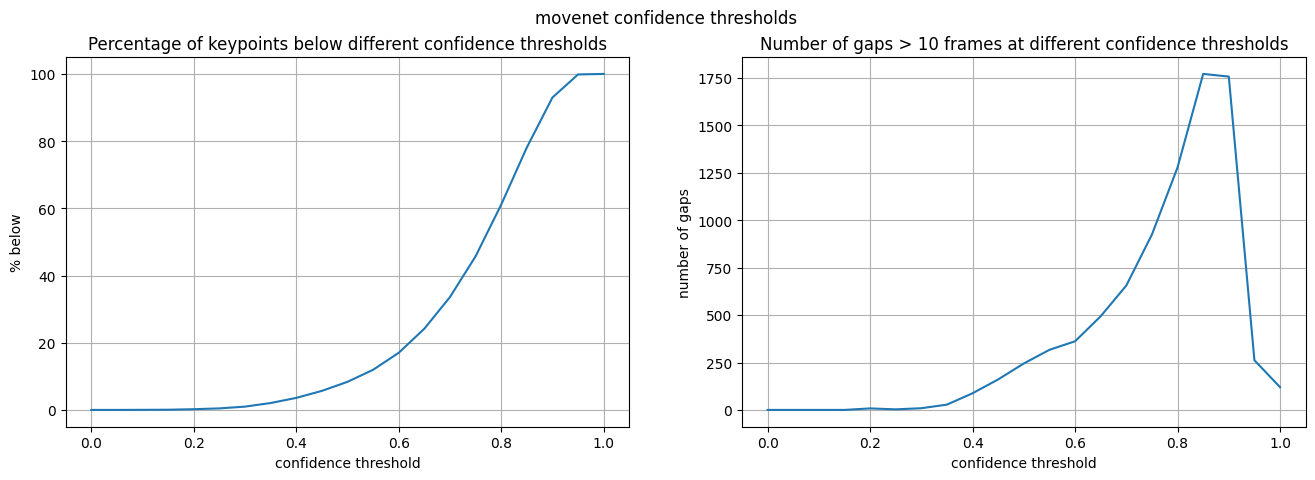

In [388]:
run_analysis(movenet_files, THRESHOLDS, 'confidence', MAX_ALLOWED_GAP_SIZE, 'movenet', OUT_DIR)

## Mediapipe

    visibility     % below  gaps > 10
0         0.00    0.000000          0
1         0.05    0.000000          0
2         0.10    0.178215          4
3         0.15    0.425272         12
4         0.20    1.401288         44
5         0.25    2.336775         63
6         0.30    3.180102         78
7         0.35    4.055074         90
8         0.40    5.263158        125
9         0.45    6.925383        142
10        0.50    8.358317        161
11        0.55    9.964468        181
12        0.60   11.593937        190
13        0.65   13.352210        183
14        0.70   15.810571        203
15        0.75   18.031312        203
16        0.80   20.954919        249
17        0.85   24.482567        248
18        0.90   28.313902        244
19        0.95   35.589607        235
20        1.00  100.000000        120


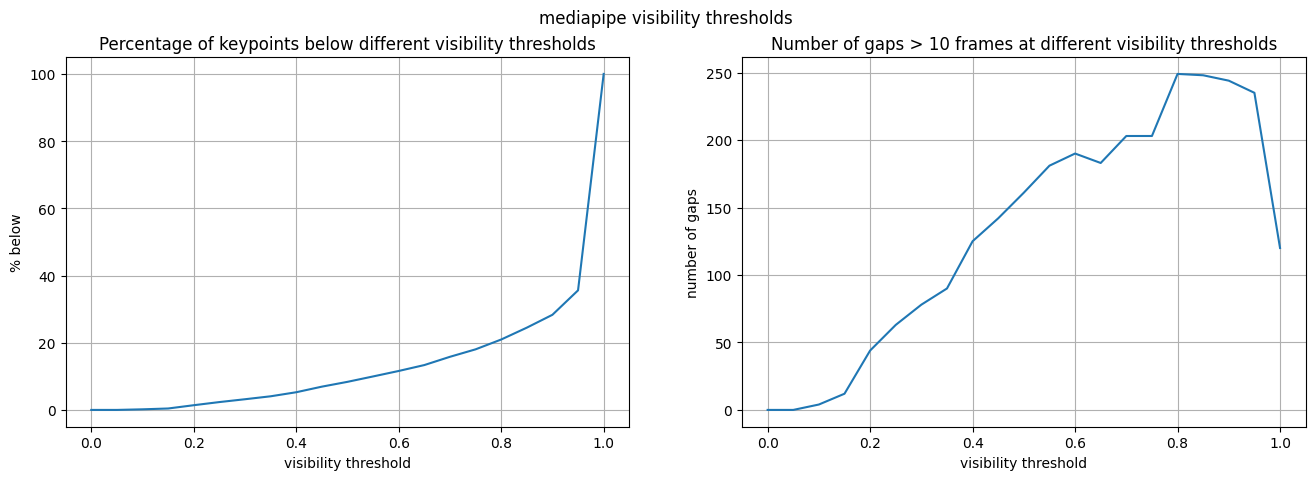

In [389]:
run_analysis(mediapipe_files, THRESHOLDS, 'visibility', MAX_ALLOWED_GAP_SIZE, 'mediapipe', OUT_DIR)